<a href="https://colab.research.google.com/github/varshacode01/varshacode01/blob/main/Predictive_Quality_Control_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code models the following:

1. Simulates material batch data like Venostent might have.

3. Defines a simple pass/fail rule to generate labels.

3. Trains a Random Forest model to predict failures.

4. Scores each batch with a risk probability.

5. Identifies top at-risk batches.

6. Visualizes trends in the data to highlight key features.

Sample Batch Data:
   viscosity  thickness  tensile_strength  degradation_rate  pass_fail
0   5.248357   0.516204         42.923146         10.500986          0
1   4.930868   0.480746         47.896773         10.692896          1
2   5.323844   0.466154         48.286427          8.639951          1
3   5.761515   0.530584         45.988614         10.464507          0
4   4.882923   0.551550         49.193571         10.586145          0

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10

Confusion Matrix:
[[9 0]
 [1 0]]

Top 5 At-Risk Batches:
    viscosity  thickness  tensile_strength  degradation_rate  pass_fail  \
46   4.769681   0.514806         43.815246          8.232285          0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


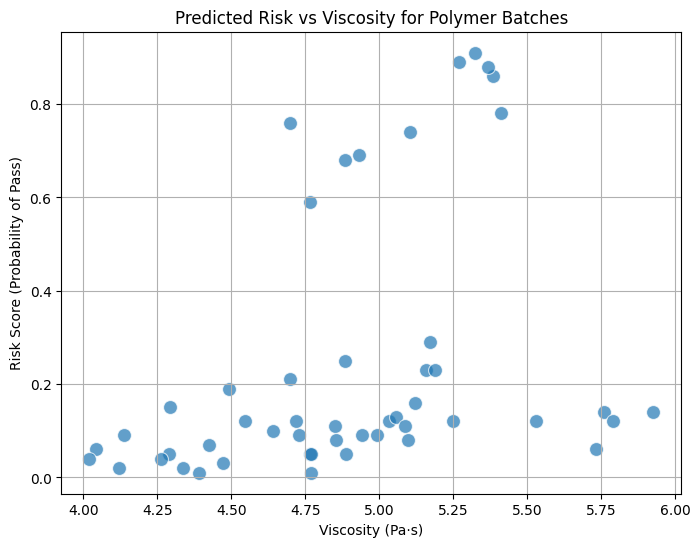

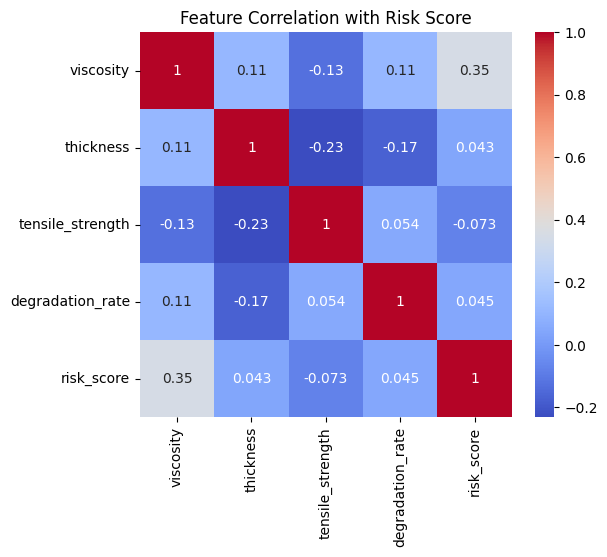

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Generate dummy batch data

np.random.seed(42)  # reproducible

num_batches = 50
data = pd.DataFrame({
    "viscosity": np.random.normal(5, 0.5, num_batches),           # Pa·s
    "thickness": np.random.normal(0.5, 0.05, num_batches),        # mm
    "tensile_strength": np.random.normal(50, 5, num_batches),     # MPa
    "degradation_rate": np.random.normal(10, 2, num_batches)      # %/week
})

# Simple rule for pass/fail: fail if any property is too extreme
data["pass_fail"] = ((data["viscosity"].between(4.5,5.5)) &
                     (data["thickness"].between(0.45,0.55)) &
                     (data["tensile_strength"].between(45,55)) &
                     (data["degradation_rate"].between(8,12))).astype(int)

print("Sample Batch Data:")
print(data.head())


#  Split data into train/test

X = data[["viscosity", "thickness", "tensile_strength", "degradation_rate"]]
y = data["pass_fail"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Train a predictive model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # probability of passing


#  Evaluate the model

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Add risk score to all batches

data["risk_score"] = model.predict_proba(X)[:,1]  # higher = more likely to pass

# Identify top 5 at-risk batches
at_risk = data.sort_values("risk_score").head(5)
print("\nTop 5 At-Risk Batches:")
print(at_risk)


#  Visualizations

# Scatter plot: Viscosity vs Risk Score
plt.figure(figsize=(8,6))
sns.scatterplot(x="viscosity", y="risk_score", data=data, s=100, alpha=0.7)
plt.xlabel("Viscosity (Pa·s)")
plt.ylabel("Risk Score (Probability of Pass)")
plt.title("Predicted Risk vs Viscosity for Polymer Batches")
plt.grid(True)
plt.show()

# Heatmap: Feature correlation with risk
plt.figure(figsize=(6,5))
sns.heatmap(data[["viscosity","thickness","tensile_strength","degradation_rate","risk_score"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Risk Score")
plt.show()
